In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
dataset_path = "/content/drive/MyDrive/Apple"

In [11]:
import os

classes = [cls for cls in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, cls))]
print("Classes:", classes)

for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    print(cls, len(os.listdir(cls_path)))

Classes: ['Powdery Mildew', 'Black Pox', 'Anthracnose', 'Healthy', 'Black Rot']
Powdery Mildew 520
Black Pox 460
Anthracnose 341
Healthy 713
Black Rot 666


In [12]:
import os
import hashlib

dataset_path = "/content/drive/MyDrive/Apple"

def file_hash(path):
    hasher = hashlib.md5()
    with open(path, 'rb') as f:
        hasher.update(f.read())
    return hasher.hexdigest()

print("Checking & removing duplicates...")

for cls in os.listdir(dataset_path):
    cls_path = os.path.join(dataset_path, cls)
    if not os.path.isdir(cls_path):
        continue

    seen = set()
    removed = 0

    for img in os.listdir(cls_path):
        if not img.lower().endswith(('.jpg','.jpeg','.png')):
            continue

        path = os.path.join(cls_path, img)
        h = file_hash(path)

        if h in seen:
            os.remove(path)
            removed += 1
        else:
            seen.add(h)

    print(f"{cls}: removed {removed}")

print("✅ Duplicate check complete")

Checking & removing duplicates...
Powdery Mildew: removed 0
Black Pox: removed 0
Anthracnose: removed 0
Healthy: removed 0
Black Rot: removed 0
✅ Duplicate check complete


In [13]:
import os
import shutil
import random

base_path = "/content/drive/MyDrive/Apple"
output_path = "/content/drive/MyDrive/processed_dataset"

split_ratio = (0.8, 0.2)  # train, val

for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)
    if not os.path.isdir(cls_path):
        continue

    images = [img for img in os.listdir(cls_path) if img.lower().endswith(('.jpg','.png','.jpeg'))]
    random.shuffle(images)

    split = int(len(images) * split_ratio[0])

    train_imgs = images[:split]
    val_imgs = images[split:]

    for split_name, split_imgs in zip(['train','val'], [train_imgs, val_imgs]):
        split_folder = os.path.join(output_path, split_name, cls)
        os.makedirs(split_folder, exist_ok=True)

        for img in split_imgs:
            shutil.copy(os.path.join(cls_path, img), os.path.join(split_folder, img))

print("✅ Split done")

✅ Split done


In [19]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

train_path = "/content/drive/MyDrive/processed_dataset/train"
val_path = "/content/drive/MyDrive/processed_dataset/val"

# ✅ Correct preprocessing for EfficientNet
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 2158 images belonging to 5 classes.
Found 542 images belonging to 5 classes.


In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get class labels from generator
y = train_generator.classes

# Compute weights
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y),
    y=y
)

# Convert to dictionary
class_weights = dict(enumerate(class_weights_array))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(1.5867647058823529), 1: np.float64(1.1728260869565217), 2: np.float64(0.8112781954887218), 3: np.float64(0.7571929824561403), 4: np.float64(1.0375)}


In [16]:
print(train_generator.class_indices)

{'Anthracnose': 0, 'Black Pox': 1, 'Black Rot': 2, 'Healthy': 3, 'Powdery Mildew': 4}


In [21]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze ALL layers
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

outputs = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

# Compile
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Model ready")

✅ Model ready


In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 86s 931ms/step - accuracy: 0.4861 - loss: 1.3746 - val_accuracy: 0.7731 - val_loss: 1.1013
Epoch 2/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 42s 625ms/step - accuracy: 0.7549 - loss: 0.6583 - val_accuracy: 0.8266 - val_loss: 0.7748
Epoch 3/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 42s 620ms/step - accuracy: 0.7966 - loss: 0.5159 - val_accuracy: 0.8561 - val_loss: 0.5593
Epoch 4/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 42s 621ms/step - accuracy: 0.8471 - loss: 0.4076 - val_accuracy: 0.8708 - val_loss: 0.4293
Epoch 5/5
68/68 ━━━━━━━━━━━━━━━━━━━━ 43s 633ms/step - accuracy: 0.8559 - loss: 0.3811 - val_accuracy: 0.8893 - val_loss: 0.3535
Restoring model weights from the end of the best epoch: 5.


In [23]:
# Unfreeze last 30 layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # very important (LOW LR)
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ Fine-tuning ready")

✅ Fine-tuning ready


In [24]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping

# Save best model
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Reduce LR if stuck
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

# Early stopping (optional safety)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

# Train
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

Epoch 1/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.6923 - loss: 0.8304
Epoch 1: val_accuracy improved from None to 0.86347, saving model to /content/drive/MyDrive/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 0.7006 - loss: 0.8011 - val_accuracy: 0.8635 - val_loss: 0.3539 - learning_rate: 1.0000e-05
Epoch 2/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.7553 - loss: 0.6788
Epoch 2: val_accuracy did not improve from 0.86347
68/68 ━━━━━━━━━━━━━━━━━━━━ 41s 603ms/step - accuracy: 0.7646 - loss: 0.6466 - val_accuracy: 0.8616 - val_loss: 0.3552 - learning_rate: 1.0000e-05
Epoch 3/10
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.7703 - loss: 0.5883
Epoch 3: val_accuracy did not improve from 0.86347
68/68 ━━━━━━━━━━━━━━━━━━━━ 42s 611ms/step - accuracy: 0.7790 - loss: 0.5862 - val_accuracy: 0.8598 - val_loss: 0.3527 - learning_rate: 1.0000e-05
Epoch 4/10
68/68 ━━━━

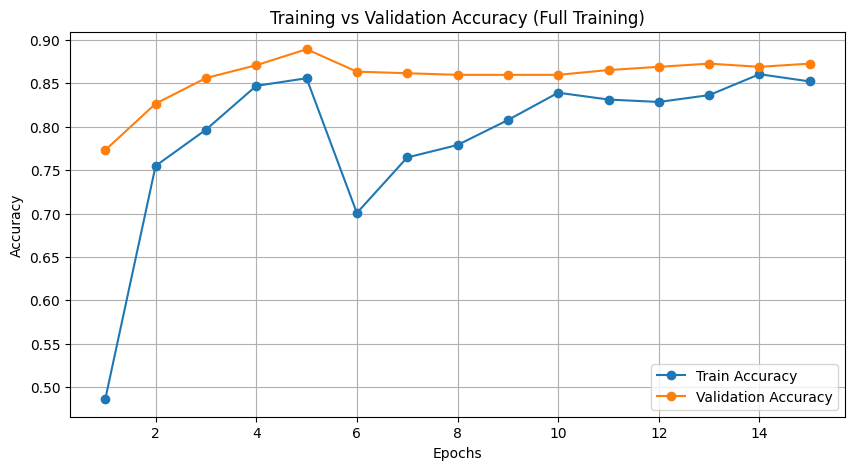

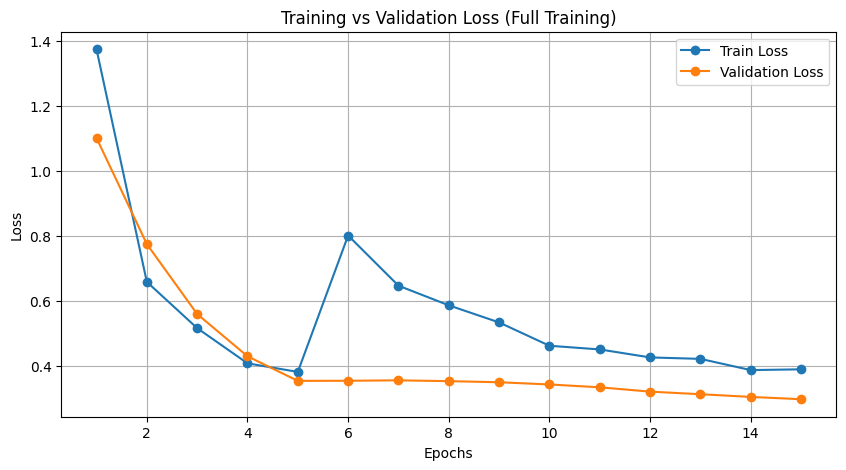

In [25]:
import matplotlib.pyplot as plt

# 🔹 Combine histories
acc = history.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history.history['val_accuracy'] + history_finetune.history['val_accuracy']

loss = history.history['loss'] + history_finetune.history['loss']
val_loss = history.history['val_loss'] + history_finetune.history['val_loss']

# Epochs
epochs = range(1, len(acc) + 1)

# 🔹 Accuracy Graph
plt.figure(figsize=(10,5))
plt.plot(epochs, acc, marker='o', label='Train Accuracy')
plt.plot(epochs, val_acc, marker='o', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy (Full Training)')
plt.legend()
plt.grid()
plt.show()

# 🔹 Loss Graph
plt.figure(figsize=(10,5))
plt.plot(epochs, loss, marker='o', label='Train Loss')
plt.plot(epochs, val_loss, marker='o', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Full Training)')
plt.legend()
plt.grid()
plt.show()

Saving Anth.jpeg to Anth.jpeg


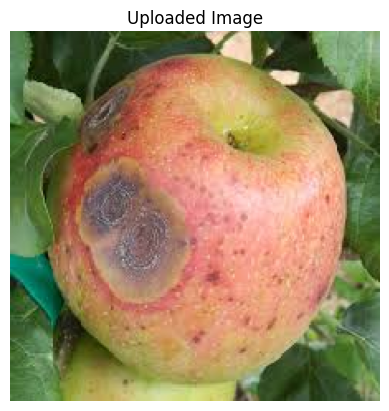

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
🔍 Prediction: Anthracnose
📊 Confidence: 0.8925771713256836


In [33]:
# 🔹 Load model (run once)
from tensorflow.keras.models import load_model
model = load_model("/content/drive/MyDrive/best_model.keras")

# 🔹 Imports
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from google.colab import files
import matplotlib.pyplot as plt

# 🔹 Class names (VERY IMPORTANT)
class_names = ['Anthracnose', 'Black Pox', 'Black Rot', 'Healthy', 'Powdery Mildew']

# 🔹 Upload + Predict
uploaded = files.upload()

for img_name in uploaded.keys():
    # Load image
    img = image.load_img(img_name, target_size=(224,224))

    # Show image
    plt.imshow(img)
    plt.axis('off')
    plt.title("Uploaded Image")
    plt.show()

    # Preprocess
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Predict
    preds = model.predict(img_array)
    class_idx = np.argmax(preds)
    confidence = np.max(preds)

    # Output
    print("🔍 Prediction:", class_names[class_idx])
    print("📊 Confidence:", float(confidence))

In [ ]:
#RUN ONLY BELOW CODE IT IS GOING TO CONNECT DRIVE AND WE CAN UPLOAD IMAGE IT IS GOING TO PREDICT AND SHOW THE RESULTS

In [ ]:
# 🔹 1. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 🔹 2. Import libraries
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import load_model
from google.colab import files

# 🔹 3. Load model
model = load_model("/content/drive/MyDrive/best_model.keras")

# 🔹 4. Class names (VERY IMPORTANT - keep same order)
class_names = ['Anthracnose', 'Black Pox', 'Black Rot', 'Healthy', 'Powdery Mildew']

print("✅ Model Loaded Successfully!")

# 🔹 5. Upload image
uploaded = files.upload()

# 🔹 6. Predict
for img_name in uploaded.keys():
    img = image.load_img(img_name, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    img_array = preprocess_input(img_array)

    preds = model.predict(img_array)
    class_idx = np.argmax(preds)

    print("\n📸 Image:", img_name)
    print("🌿 Prediction:", class_names[class_idx])
    print("📊 Confidence:", float(np.max(preds)))